# **Fine Tune With Adapters**

#### **Import Libraries**

In [1]:
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, BertForSequenceClassification, BertTokenizer
from tqdm import tqdm
from torch.utils.data import Dataset
import math
from torch.utils.data import random_split 
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
import time

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Dataset Configuration**

In [2]:
dataset = load_dataset("imdb")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [3]:
train_dataset = dataset['train']
test_dataset = dataset['test']

In [4]:
train_dataset[0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [5]:
label_list = []
for id , (text, label) in enumerate(train_dataset):
    label_list.append(train_dataset[id]['label'])

num_labels = len(set(label_list))
num_labels    

2

In [6]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
tokenizer

BertTokenizer(name_or_path='bert-base-cased', vocab_size=28996, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [7]:
lmdb_labels = {0: "negatice review", 1: "positive review"}

In [8]:
label_col = train_dataset.select_columns('label')
label_col

Dataset({
    features: ['label'],
    num_rows: 25000
})

In [9]:
len(train_dataset)

25000

In [10]:
imdb_labels = {0: "negative review", 1: "positive review"}

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device.type

'cuda'

### **Define Dataset Class**

In [12]:
class ClassificationDataset(Dataset):
    
    def __init__(self,dataset,tokenizer: AutoTokenizer, max_length:int = 500):
        super().__init__()
        self.max_length = max_length
        self.tokenizer = tokenizer
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        item = self.dataset[index]
        
        encodings = self.tokenizer(
            item['text'],
            return_tensors = 'pt',
            max_length = self.max_length,
            truncation = True,
            padding = 'max_length'
        )
        label_tenosr = torch.tensor(item['label'], dtype=torch.int64)
        return encodings['input_ids'].squeeze(0), encodings['attention_mask'].squeeze(0), label_tenosr
        

In [13]:
dataset_train = ClassificationDataset(train_dataset, tokenizer)
dataset_test = ClassificationDataset(test_dataset, tokenizer)

In [14]:
for i in range(-10,10):
    print(dataset_train[i])

(tensor([  101,  2409,   146,  1163,  1157,   170,  4610,  3774,   119,  1135,
         1218,  1637,  1218,  5376,  1105,  1218,  2641,   119,   146,  3851,
         1917,  1107,  1142,  2523,   119,  4785,  1157,  4613,  1155,  1268,
         1133,  1103, 18044,  1334,   119, 26876,  8125,  7174,  1110,  1632,
         1107,  1142,  1105,   146,   112,   182,  5733,  2903,  1451,  2523,
         1114,  1123,  1107,  1115,   146,  1169,  1243,  1139,  1493,  1113,
          119,  2119,  3869,   170,  1440,   119,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,

#### **Define the Tokenization and Dataloaders Based on Hugging Face**

In [15]:
def tokenize_text (data):
    return tokenizer(
        data['text'],
        max_length = 256,
        truncation = True,
        padding = 'max_length'
    )

In [16]:
dataset = dataset.map(tokenize_text,batched=True)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

In [17]:
dataset = dataset.rename_column('label','labels')
dataset.set_format(type='torch', columns=['labels', 'input_ids', 'attention_mask'])

In [18]:
dataset.column_names

{'train': ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
 'test': ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
 'unsupervised': ['text',
  'labels',
  'input_ids',
  'token_type_ids',
  'attention_mask']}

##### **Define Dataloaders**

**Splits Train Dataset**

In [19]:
train_valid_split = dataset['train'].train_test_split(test_size=0.1, seed=42)

In [20]:
train_dataloader = DataLoader(train_valid_split['train'], batch_size=8, shuffle=True)
valid_datalaoder = DataLoader(train_valid_split['test'], batch_size=8, shuffle=False)
test_dataloader = DataLoader(dataset['test'], batch_size=8, shuffle=False)

In [21]:
batch = next(iter(train_dataloader))
print(batch, batch['input_ids'].shape)

{'labels': tensor([1, 1, 0, 1, 1, 0, 1, 0]), 'input_ids': tensor([[  101,  2408,  3761,  ...,  1198,   170,   102],
        [  101,   146,  3983,  ...,     0,     0,     0],
        [  101,  1622,  3455,  ...,  1129,  7345,   102],
        ...,
        [  101,  1327,  1110,  ...,     0,     0,     0],
        [  101,  1130,  1103,  ...,   170,  3963,   102],
        [  101, 21570,  5957,  ...,   188,  1121,   102]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])} torch.Size([8, 256])


### **Custom Model Build**

##### **Text Embedding**

In [22]:
class TextEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, dropout ):
        super().__init__()
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)
        
        self.embedding = nn.Embedding(vocab_size,d_model)
        
    def forward(self, input_tokens):
        
        #input_tokens -> [batch_size, seq_len]
        embed_out = self.embedding(input_tokens) * math.sqrt(self.d_model)
        return self.dropout(embed_out)

#### **Positional Embeddings**

In [23]:
class PositionalEmbeddings (nn.Module):
    
    def __init__(self, max_seq_len, d_model, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
        positions = torch.arange(0, max_seq_len).unsqueeze(1)
        
        pe =  torch.zeros(max_seq_len, d_model)
        
        div_term = torch.exp(
            torch.arange(0,d_model,2).float() * (-math.log(10000)/ d_model)
        )
        
        pe[:,0::2] = torch.sin(positions * div_term)
        pe[:,1::2] = torch.cos(positions * div_term)
        
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
        
    def forward(self, word_embeddings):
        
        #word_embeddings -> [batch_size, seq_len, d_model]
        word_embedding_size = word_embeddings.size(1)
        
        pos_embeddings = word_embeddings + self.pe[:,0:word_embedding_size,:]
        return self.dropout(pos_embeddings)
        
        

#### **Custom Model Class**

In [24]:
class CustomClassificationModel (nn.Module):
    
    def __init__(self, vocab_size, d_model, 
                n_layers, n_heads, dropout, dim_feedforward, max_seq_len = 1000):
        super().__init__()
        self.d_model = d_model
        self.embeddings = TextEmbedding(vocab_size,d_model, dropout)
        self.pos_embeddings = PositionalEmbeddings(max_seq_len,d_model,dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model,n_heads,dropout=dropout,batch_first=True,dim_feedforward=dim_feedforward)
        
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer=encoder_layer,
                                                        num_layers=n_layers)
        
        self.linear_layer = nn.Linear(in_features=d_model, out_features=2)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_ids, attention_mask = None):
        
        embed_out = self.embeddings(input_ids) 
        pos_out = self.pos_embeddings(embed_out)
        
        src_key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        
        transformer_out = self.transformer_encoder(pos_out, src_key_padding_mask = src_key_padding_mask)
        transformer_out = transformer_out.mean(dim = 1)
        
        transformer_out = self.dropout(transformer_out)
        classify_out = self.linear_layer(transformer_out)
        
        return classify_out

#### **Model Instance Define**

In [25]:
vocab_size = tokenizer.vocab_size
n_heads = 4
d_model = 256
n_layers = 4
dropout = 0.1
dim_feedforward = 512

In [26]:
classify_model = CustomClassificationModel(vocab_size=vocab_size,d_model=d_model,n_layers=n_layers,
                                           n_heads=n_heads, dropout=dropout,
                                           dim_feedforward=dim_feedforward)

In [27]:
classify_model.to(device)

CustomClassificationModel(
  (embeddings): TextEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
    (embedding): Embedding(28996, 256)
  )
  (pos_embeddings): PositionalEmbeddings(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (linear_layer): Linear(in_features=256, out_

#### **Define Model Predict** 

In [28]:
def model_predict (model:CustomClassificationModel, input_sentence, tokenizer:AutoTokenizer):
    
    with torch.no_grad():
        
        tokens = tokenizer(input_sentence, return_tensors='pt', truncation=True).to(device)
        input_ids = tokens['input_ids']
        attention_mask = tokens['attention_mask']
        
        output = model(input_ids, attention_mask)
        predict = torch.argmax(output, dim=-1)
        
        predict_label = imdb_labels[predict.item()]
        
        return predict_label

In [29]:
sample = "I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967."
predict_label = model_predict(classify_model,sample, tokenizer)
predict_label

'positive review'

#### **Define Model Evaluation**

In [30]:
def model_eval(model:CustomClassificationModel, dataloader:DataLoader):
    
    total_accuracy = []
    loss_epochs = []
    total_count = 0
    accuracy =0 
    
    model.eval()
    
    with torch.no_grad():
        
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            label = batch['labels']
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            
            output = model(input_ids, attention_mask)
            predict = torch.argmax(output, dim=-1)
            accuracy += (predict == label).sum().item()
            total_count += label.size(0)
            
    return accuracy/total_count

In [31]:
accuracy = model_eval(classify_model,test_dataloader)

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


In [32]:
accuracy

0.49272

#### **Define Model Train**

In [33]:
LR = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classify_model.parameters(),lr=LR)

In [34]:
num_epochs = 5
total_steps = num_epochs * len(train_dataloader)
warm_steps = int(total_steps * 0.1)

lr_scheduler = get_linear_schedule_with_warmup(optimizer,
                                               num_warmup_steps=warm_steps,
                                               num_training_steps=total_steps) 

In [35]:
def model_train (model:CustomClassificationModel, dataloader:DataLoader, 
                optimizer:AdamW, criterion:CrossEntropyLoss, lr_scheduler, n_epochs = num_epochs):
    
    
    total_loss = []
    total_accuracy = []
    acc_old = 0
    
    start_time = time.time()
    
    for epoch in tqdm(range(1, n_epochs+1)):
        model.train()
        epoch_loss = 0
        
        for batch in dataloader:
            
            batch = {k:v.to(device) for k,v in batch.items()}
            labels = batch["labels"]
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            
            optimizer.zero_grad()
            output = model(input_ids, attention_mask)
            
            #loss calculate
            loss = criterion(output, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(),1)
            optimizer.step()
            lr_scheduler.step()
            
            epoch_loss += loss.item() 
            
        epoch_loss = epoch_loss / len(dataloader)
            
        print(f"Epoch {epoch}/{n_epochs} - Loss: {epoch_loss}")  
        total_loss.append(epoch_loss)
        accuracy_val = model_eval(model, valid_datalaoder)
        total_accuracy.append(accuracy_val)
        print(f"Epoch {epoch}/{n_epochs} - accuracy: {accuracy_val}")  
        if accuracy_val>acc_old:
            acc_old = accuracy_val
            
            print("save model epoch",epoch)
            torch.save(model.state_dict(), "classification-model.pt")
        
    end_time = time.time()
    
    print("training time: ", end_time-start_time)
    return total_accuracy, total_loss
    

In [36]:
model_accuracy, model_loss = model_train(classify_model, train_dataloader,
                                        optimizer,criterion, lr_scheduler)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 0.6020771134797043


 20%|██        | 1/5 [01:33<06:12, 93.03s/it]

Epoch 1/5 - accuracy: 0.7624
save model epoch 1
Epoch 2/5 - Loss: 0.48999243769947


 40%|████      | 2/5 [03:15<04:55, 98.43s/it]

...

Epoch 3/5 - accuracy: 0.806
save model epoch 3
Epoch 4/5 - Loss: 0.4275191007953414


 80%|████████  | 4/5 [07:00<01:48, 108.31s/it]

Epoch 4/5 - accuracy: 0.8116
save model epoch 4
Epoch 5/5 - Loss: 0.40736672029473947


100%|██████████| 5/5 [09:02<00:00, 108.41s/it]

Epoch 5/5 - accuracy: 0.8148
save model epoch 5
training time:  542.0708065032959


In [37]:
print("Device:", device)
print("Model on GPU:", next(classify_model.parameters()).is_cuda)
print("CUDA available:", torch.cuda.is_available())

# if GPU available, also check which one:
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Memory allocated:", torch.cuda.memory_allocated(0) / 1e9, "GB")

Device: cuda
Model on GPU: True
CUDA available: True
GPU name: NVIDIA GeForce GTX 1660 Ti
Memory allocated: 0.171624448 GB


#### **Plot the Outcomes**

In [38]:
def plot_model (model_accuracy, model_loss):
    fig, ax1 = plt.subplots()
    color = 'tab:green'
    ax1.plot(model_accuracy, color = color)
    ax1.set_label("Model accuracy")
    ax1.set_xlabel("epochs")
    ax1.set_ylabel("accuracy")

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.plot(model_loss, color = color)
    ax2.set_label("Model Loss")
    ax2.set_ylabel("loss")
    ax2.tick_params(axis='y', color=color)

    plt.tight_layout()
    plt.show()


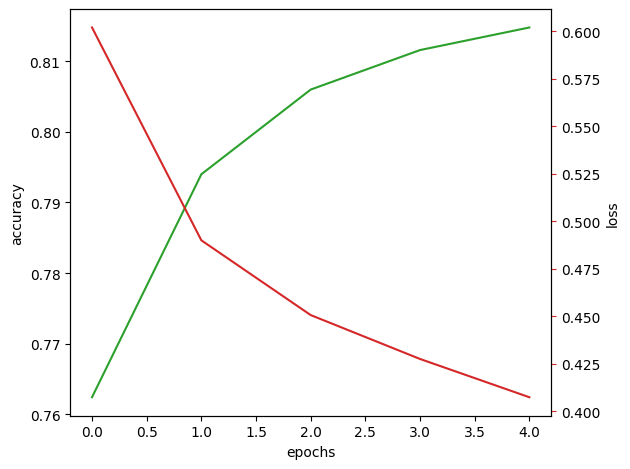

In [39]:
plot_model(model_accuracy,model_loss)

# Adapters

FeatureAdapter is a neural network component designed to improve transformer models through parameter-efficient fine-tuning. It introduces a low-dimensional bottleneck structure that reduces the size of high-dimensional embeddings, applies a non-linear transformation, and then restores them to their original dimensions. A residual connection is then used to combine the transformed output with the original input, helping preserve important information and maintain stable gradient flow during training.

## Advantages of Using Adapters in Neural Networks

- **Efficient fine-tuning**: Adapters enable selective modification of certain model components, avoiding the need to retrain the entire network.

- **Parameter efficiency**: Since adapters add only a small number of trainable parameters, they reduce computational and memory requirements for large models.

- **Retention of pretrained knowledge**: They allow models to adapt to new tasks while keeping the useful representations learned during pretraining.

- **Flexibility and modularity**: Adapters make models easier to customize for different applications without changing the main architecture.

- **Task-oriented optimization**: They can be specialized for particular tasks, improving performance in targeted applications.

- **Transfer learning and domain adaptation**: Adapters help models generalize to new domains and datasets with different data distributions.

- **Support for continual learning**: They allow models to learn additional tasks over time while minimizing the loss of previously learned knowledge.

- **Lower overfitting risk**: Because only a small number of parameters are trained, adapters can reduce overfitting, particularly when working with limited data.

The code below demonstrates an implementation of an adapter model.

In [36]:
#load the model
new_classify_model = CustomClassificationModel(vocab_size=vocab_size,d_model=d_model,n_layers=n_layers,
                                           n_heads=n_heads, dropout=dropout,
                                           dim_feedforward=dim_feedforward)


In [37]:
new_classify_model.load_state_dict(torch.load("classification-model.pt", map_location=device))

<All keys matched successfully>

In [38]:
class FeatureAdapter (nn.Module):
    
    def __init__(self, d_model, bottlenech_dim):
        super().__init__()
        
        self.compress_layer  = nn.Linear(d_model, bottlenech_dim)
        self.activation_layer = nn.GELU()
        self.expand_layer = nn.Linear(bottlenech_dim, d_model)
    
    def forward(self, input):
        com_out = self.compress_layer(input)
        act_out = self.activation_layer(com_out)
        exp_out = self.expand_layer(act_out)
        
        #add residual conncetion to reduce overfit
        residual_out = exp_out + input
        return residual_out

In [39]:
new_classify_model.transformer_encoder.layers

ModuleList(
  (0-3): 4 x TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (linear1): Linear(in_features=256, out_features=512, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=512, out_features=256, bias=True)
    (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
)

In [40]:
new_classify_model.transformer_encoder.layers[0].linear1

Linear(in_features=256, out_features=512, bias=True)

In [41]:
new_classify_model.transformer_encoder.layers[0].linear2

Linear(in_features=512, out_features=256, bias=True)

#### **Define Adapter Class**

In [42]:
class Adapter (nn.Module):
    
    def __init__(self, linear:nn.Linear, bottleneck_dim=None):
        super().__init__()
        
        self.linear = linear
        model_dim = linear.out_features
        self.weight = linear.weight
        self.bias = linear.bias
        
        if bottleneck_dim is None:
            bottleneck_dim = model_dim // 2
            
        self.adaptor = FeatureAdapter(model_dim, bottleneck_dim)
        
    def forward (self, input):
        
        out = self.linear(input)
        adap_out = self.adaptor(out)
        
        return adap_out

#### **Adding Adapter Layer to Tansformer Encoder Layers**

In [43]:
# first need to freeze the all parameters
for param in new_classify_model.parameters():
    param.requires_grad = False

In [44]:
my_adapter_layer = Adapter(new_classify_model.linear_layer)
my_adapter_layer

Adapter(
  (linear): Linear(in_features=256, out_features=2, bias=True)
  (adaptor): FeatureAdapter(
    (compress_layer): Linear(in_features=2, out_features=1, bias=True)
    (activation_layer): GELU(approximate='none')
    (expand_layer): Linear(in_features=1, out_features=2, bias=True)
  )
)

In [45]:
for param in my_adapter_layer.parameters():
    print(param.requires_grad)

False
False
True
True
True
True


# Adapter Parameter Summary

## requires_grad Status

| Parameter | Shape | Count | Status |
|---|---|---|---|
| `linear.weight` | `[2, 256]` | 512 | ❌ Frozen |
| `linear.bias` | `[2]` | 2 | ❌ Frozen |
| `adaptor.compress_layer.weight` | `[128, 256]` | 32,768 | ✅ Training |
| `adaptor.compress_layer.bias` | `[128]` | 128 | ✅ Training |
| `adaptor.expand_layer.weight` | `[256, 128]` | 32,768 | ✅ Training |
| `adaptor.expand_layer.bias` | `[256]` | 256 | ✅ Training |

## Summary

| | Params |
|---|---|
| **Frozen** | 514 |
| **Trainable** | 65,920 |
| **Total** | 66,434 |


In [46]:
# should update transformer_encoder.linear layers with my_adapter_layer
#classify_model.transformer_encoder.layers[0].linear1 = my_adapter_layer

**Beacause we have multi transformer encoder layers, we need to update each linear layer f transformer encoder layer individually**

In [47]:
num_layers = len(new_classify_model.transformer_encoder.layers)
print(f"number of layers: {num_layers}")

number of layers: 4


In [48]:
for n in range(num_layers):
    
    encoder = new_classify_model.transformer_encoder.layers[n]
    
    if encoder.linear1:
        print("Before linear1")
        print(encoder.linear1)
        new_classify_model.transformer_encoder.layers[n].linear1 =  Adapter(encoder.linear1, bottleneck_dim=24)
        print("After linear1")
        print(new_classify_model.transformer_encoder.layers[n].linear1)
    
    if encoder.linear2:
        print("Before linear2")
        print(encoder.linear2)
        new_classify_model.transformer_encoder.layers[n].linear2 = Adapter(encoder.linear2, bottleneck_dim=24)
        print("After linear2")
        print(new_classify_model.transformer_encoder.layers[n].linear2)

Before linear1
Linear(in_features=256, out_features=512, bias=True)
After linear1
Adapter(
  (linear): Linear(in_features=256, out_features=512, bias=True)
  (adaptor): FeatureAdapter(
    (compress_layer): Linear(in_features=512, out_features=24, bias=True)
    (activation_layer): GELU(approximate='none')
    (expand_layer): Linear(in_features=24, out_features=512, bias=True)
  )
)
Before linear2
Linear(in_features=512, out_features=256, bias=True)
After linear2
Adapter(
  (linear): Linear(in_features=512, out_features=256, bias=True)
  (adaptor): FeatureAdapter(
    (compress_layer): Linear(in_features=256, out_features=24, bias=True)
    (activation_layer): GELU(approximate='none')
    (expand_layer): Linear(in_features=24, out_features=256, bias=True)
  )
)
Before linear1
Linear(in_features=256, out_features=512, bias=True)
After linear1
Adapter(
  (linear): Linear(in_features=256, out_features=512, bias=True)
  (adaptor): FeatureAdapter(
    (compress_layer): Linear(in_features=51

In [49]:
for param in new_classify_model.transformer_encoder.layers[0].parameters():
    print(param.requires_grad)

False
False
False
False
False
False
True
True
True
True
False
False
True
True
True
True
False
False
False
False


In [50]:
new_classify_model.to(device)

CustomClassificationModel(
  (embeddings): TextEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
    (embedding): Embedding(28996, 256)
  )
  (pos_embeddings): PositionalEmbeddings(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Adapter(
          (linear): Linear(in_features=256, out_features=512, bias=True)
          (adaptor): FeatureAdapter(
            (compress_layer): Linear(in_features=512, out_features=24, bias=True)
            (activation_layer): GELU(approximate='none')
            (expand_layer): Linear(in_features=24, out_features=512, bias=True)
          )
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Adapter(
          (linear): Linear(in_features=512,

In [51]:
adapter_accuracy, adapter_loss = model_train(new_classify_model,train_dataloader,optimizer,
                                            criterion, lr_scheduler,n_epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 0.3947972268517696


 10%|█         | 1/10 [01:51<16:41, 111.30s/it]

Epoch 1/10 - accuracy: 0.8148
save model epoch 1
Epoch 2/10 - Loss: 0.3950742891947601


 20%|██        | 2/10 [03:40<14:38, 109.80s/it]

...

Epoch 8/10 - accuracy: 0.8148
Epoch 9/10 - Loss: 0.3971244142040838


 90%|█████████ | 9/10 [16:19<01:52, 112.20s/it]

Epoch 9/10 - accuracy: 0.8148
Epoch 10/10 - Loss: 0.39785887576358897


100%|██████████| 10/10 [18:28<00:00, 110.81s/it]

Epoch 10/10 - accuracy: 0.8148
training time:  1108.0737886428833
